## Exercise 1

You have been provided one dataset:  
Appendix 1 - xy_motion_kalman_filter_example.csv  

Your task is to leverage what you've learned in this and previous courses.  

More specifically, you will do the following:

- Make an initial estimate of your state vector and covariance matrix  
- Predict the state and covariance for the next time step  
- Computer the Kalman gain  
- Make a measurement - Update estimates of state and covariance  
- Choose a value for the estimated_model_variance that is larger than estimated_measurement_variance.  
- Repeat the analysis of section 1 for this new value.  
- Does the KF estimate converge?  
- Provide an explanation for the answer in question KF estimate.  

#### Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load Dataset

In [2]:
df=pd.read_csv("Appendix 1 - xy_motion_kalman_filter_example.csv",header=None)
df.columns = ["x", "y"]

X = df["x"].values
Y = df["y"].values

## SCENARIO 1: $Q < R$

In this scenario, the model variance is smaller than the measurement variance ($Q < R$), indicating higher confidence in the system model than in the observations.

Specifically, $Q = 0.01$ suggests that the model is considered reliable, while $R = 0.5$ indicates that the measurements contain significant noise.

As a result, the Kalman Filter produces smoother estimates, relying more on the model and filtering out measurement noise.

In [7]:
# Initial state
vx0 = X[1] - X[0]
vy0 = Y[1] - Y[0]

x_k = np.array([[X[0]],
                [vx0],
                [Y[0]],
                [vy0]])

P_k = 100 * np.eye(4)

# Model
dt = 1

F = np.array([[1, dt, 0, 0],
              [0, 1,  0, 0],
              [0, 0,  1, dt],
              [0, 0,  0, 1]])

H = np.array([[1, 0, 0, 0],
              [0, 0, 1, 0]])

# Q < R
Q = 0.01 * np.eye(4)
R = 0.5 * np.eye(2)

est_x, est_y = [], []

for k in range(len(X)):

    z = np.array([[X[k]],
                  [Y[k]]])

    # Prediction
    x_pred = F @ x_k
    P_pred = F @ P_k @ F.T + Q

    # Kalman Gain
    K = P_pred @ H.T @ np.linalg.inv(H @ P_pred @ H.T + R)

    # Update
    x_k = x_pred + K @ (z - H @ x_pred)
    P_k = (np.eye(4) - K @ H) @ P_pred

    est_x.append(x_k[0, 0])
    est_y.append(x_k[2, 0])

#### Visualization

The estimated trajectory does not pass through all the observed measurements. This occurs because the Kalman Filter assigns greater weight to the model than to the data ($Q < R$).

As a result, the filter smooths the trajectory and avoids fitting every measurement, especially those affected by noise.

The observed data exhibit variability, while the filtered trajectory follows a more stable and consistent path, capturing the underlying behavior of the system rather than the fluctuations in the measurements.

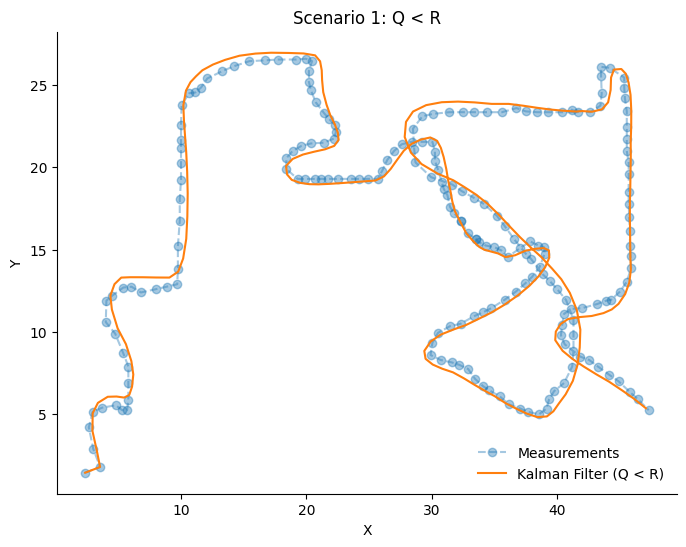

In [16]:
plt.figure(figsize=(8, 6))

plt.plot(X, Y, 'o--', alpha=0.4, label="Measurements")
plt.plot(est_x, est_y, label="Kalman Filter (Q < R)")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scenario 1: Q < R")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(frameon=False)
plt.show()

## SCENARIO 2: $Q > R$

In this scenario, the model variance is larger than the measurement variance ($Q > R$), indicating lower confidence in the model and greater trust in the observations.

Here, $Q = 1.0$ reflects higher uncertainty in the model, while $R = 0.1$ indicates that the measurements are considered more reliable.

As a result, the Kalman Filter follows the observed data more closely, producing estimates that are more responsive but also more sensitive to noise.

In [17]:
# Reinitialize state
vx0 = X[1] - X[0]
vy0 = Y[1] - Y[0]

x_k = np.array([[X[0]],
                [vx0],
                [Y[0]],
                [vy0]])

P_k = 100 * np.eye(4)

# Q > R
Q = 1.0 * np.eye(4)
R = 0.1 * np.eye(2)

est_x2, est_y2 = [], []

for k in range(len(X)):

    z = np.array([[X[k]],
                  [Y[k]]])

    # Prediction
    x_pred = F @ x_k
    P_pred = F @ P_k @ F.T + Q

    # Kalman Gain
    K = P_pred @ H.T @ np.linalg.inv(H @ P_pred @ H.T + R)

    # Update
    x_k = x_pred + K @ (z - H @ x_pred)
    P_k = (np.eye(4) - K @ H) @ P_pred

    est_x2.append(x_k[0, 0])
    est_y2.append(x_k[2, 0])

#### Visualization

In this scenario, the estimated trajectory follows the observed measurements more closely and often passes through or near the data points.

Since $Q > R$, the Kalman Filter assigns greater weight to the measurements than to the model, making it more responsive to the observed data.

As a result, the trajectory reacts more quickly to changes but also becomes more sensitive to noise, reflecting fluctuations present in the measurements.

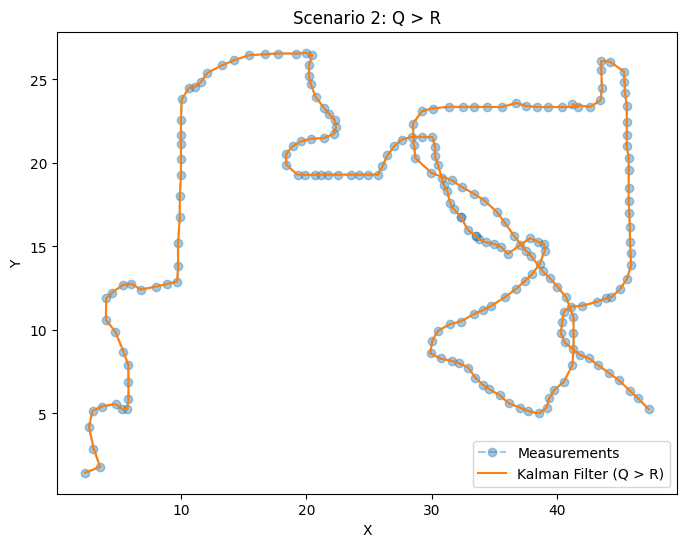

In [18]:
plt.figure(figsize=(8, 6))

plt.plot(X, Y, 'o--', alpha=0.4, label="Measurements")
plt.plot(est_x2, est_y2, label="Kalman Filter (Q > R)")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scenario 2: Q > R")
plt.legend()

plt.show()

#### Does the KF estimate converge?, Provide an explanation for the answer in question KF estimate

The results show that the Kalman Filter converges in both scenarios, as the estimated trajectories stabilize over time.

However, the behavior of the filter depends on the relationship between the model variance ($Q$) and the measurement variance ($R$).

When $Q < R$, the filter relies more on the model, producing a smoother and more stable trajectory that does not necessarily pass through all measurements.

In contrast, when $Q > R$, the filter assigns greater weight to the observations, resulting in a trajectory that follows the data more closely but is more sensitive to noise.

These results highlight the trade-off between smoothness and responsiveness in the Kalman Filter, depending on the choice of $Q$ and $R$.

#### Practical Implications

The results of the Kalman Filter demonstrate that the choice of $Q$ and $R$ has important practical implications, depending on the application.

When $Q < R$, the filter produces smoother estimates by relying more on the model. This configuration is suitable in applications where measurements are noisy and the objective is to capture the underlying trend. Examples include trajectory smoothing, economic time series analysis, and mobility pattern estimation.

In contrast, when $Q > R$, the filter becomes more responsive to measurements, making it appropriate in scenarios where data is considered reliable and rapid changes must be detected. This is common in real-time tracking systems, navigation, and high-quality sensor environments.

Therefore, the selection of $Q$ and $R$ should be guided by the level of trust in the model versus the measurements, as well as the specific objective of the analysis.

## Exercise 2

You have been provided one dataset:  
Appendix 1 - xy_motion_kalman_filter_example.csv  

This exercise refers to the dynamic one-dimensional example. In the case we examined above, the KF estimate was close to the measurements and both were different from the true value.  

Change the parameters of the algorithm until you find some combinations that achieve the following:

- Measurements, KF estimate and true value are all close.  
- Measurements, KF estimate and true value are all noticeably different.  
- The measurements are close to the true value, but the KF estimate is different.  

#### Data

The original dataset is used as a reference signal, which is treated as the true value of the system.

To simulate a realistic scenario, noisy measurements are generated by adding Gaussian noise to this reference signal.

This approach allows the evaluation of the Kalman Filter performance while preserving the structure of the original data.

In [27]:
np.random.seed(42)

true = X.copy()

# crear mediciones con ruido
noise = np.random.normal(0, 5, size=len(true))
measurements = true + noise

#### Plot

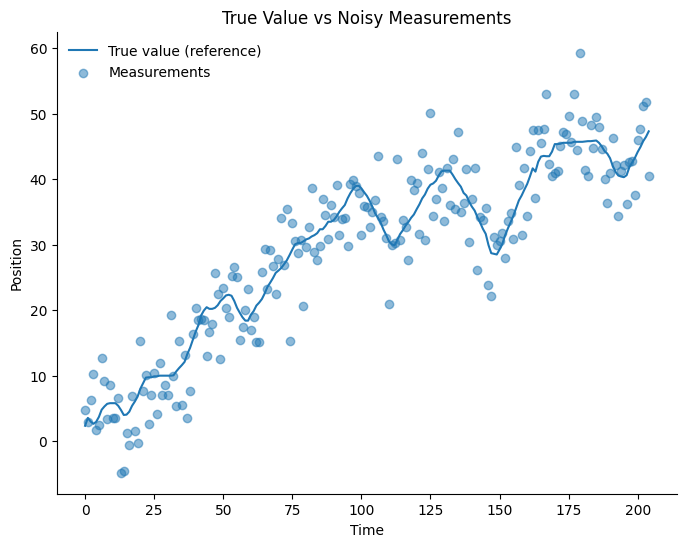

In [33]:
plt.figure(figsize=(8, 6))

plt.plot(true, label="True value (reference)")
plt.scatter(range(len(true)), measurements, alpha=0.5, label="Measurements")
plt.xlabel("Time")
plt.ylabel("Position")
plt.title("True Value vs Noisy Measurements")
plt.legend(frameon=False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

#### KALMAN FILTER 1D

A one-dimensional Kalman Filter is implemented to estimate the position of the system over time.

The state vector includes position and velocity, and the filter is applied recursively using prediction and update steps.

In [34]:
def kalman_1d(measurements, Q_val, R_val):

    n = len(measurements)

    x_k = np.array([[measurements[0]],
                    [0]])

    P_k = 100 * np.eye(2)

    dt = 1

    F = np.array([[1, dt],
                  [0, 1]])

    H = np.array([[1, 0]])

    Q = Q_val * np.eye(2)
    R = np.array([[R_val]])

    estimates = []

    for k in range(n):

        z = np.array([[measurements[k]]])

        # Prediction
        x_pred = F @ x_k
        P_pred = F @ P_k @ F.T + Q

        # Kalman Gain
        K = P_pred @ H.T @ np.linalg.inv(H @ P_pred @ H.T + R)

        # Update
        x_k = x_pred + K @ (z - H @ x_pred)
        P_k = (np.eye(2) - K @ H) @ P_pred

        estimates.append(x_k[0, 0])

    return np.array(estimates)

### Case 1 : All Close

The Kalman Filter estimate, the measurements, and the true value are relatively close, although the measurements exhibit noticeable noise. It can be observed that the measurements deviate significantly from the true value in several points, while the Kalman Filter estimate smooths these fluctuations and remains closer to the underlying trend.

The filter does not follow all measurement variations, but instead provides a balanced estimate between the noisy observations and the system model.This indicates that the Kalman Filter is well tuned, effectively reducing noise and improving the estimation compared to the raw measurements.

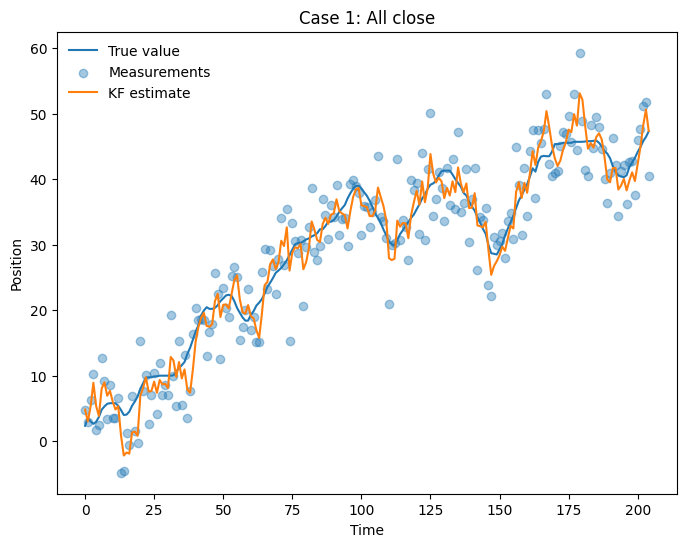

In [36]:
kf1 = kalman_1d(measurements, Q_val=0.1, R_val=5)

plt.figure(figsize=(8, 6))

plt.plot(true, label="True value")
plt.scatter(range(len(true)), measurements, alpha=0.4, label="Measurements")
plt.plot(kf1, label="KF estimate")

plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Case 1: All close")
plt.legend(frameon=False)
plt.show()

#### KF estimate and true value are all noticeably different

In this case, the measurements, the Kalman Filter estimate, and the true value are all noticeably different. The measurements show significant variability and large deviations from the true value, indicating a high level of noise in the observations. The Kalman Filter, instead of correcting these deviations, is strongly influenced by the noisy measurements and produces estimates that also remain far from the true signal.

As a result, the filter does not effectively capture the underlying behavior of the system and fails to provide an accurate estimation. This indicates that the parameter configuration does not properly balance the uncertainty of the model and the measurements. Consequently, both the measurements and the Kalman Filter estimate exhibit poor performance, highlighting the importance of proper tuning of $Q$ and $R$ in order to achieve reliable results.

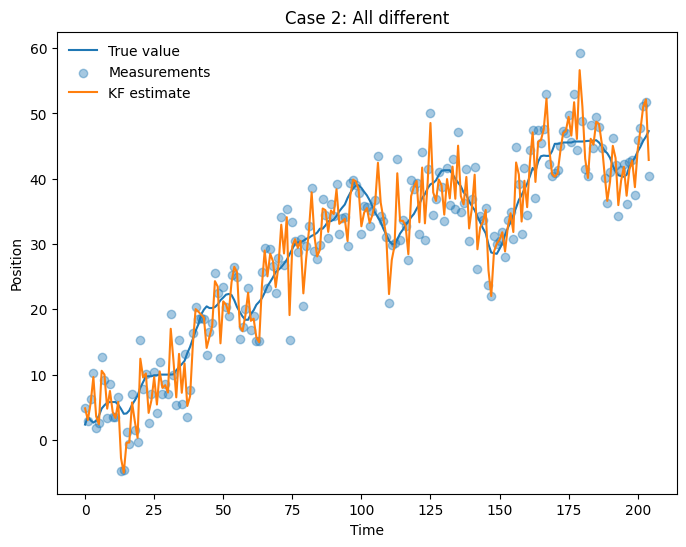

In [37]:
kf2 = kalman_1d(measurements, Q_val=10, R_val=10)
plt.figure(figsize=(8, 6))

plt.plot(true, label="True value")
plt.scatter(range(len(true)), measurements, alpha=0.4, label="Measurements")
plt.plot(kf2, label="KF estimate")

plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Case 2: All different")
plt.legend(frameon=False)
plt.show()

#### The measurements are close to the true value, but the KFestimate is different.


In this case, the measurements are relatively close to the true value, despite the presence of noise. However, the Kalman Filter estimate deviates significantly from the true signal.

While the measurements capture the general behavior of the system with reasonable accuracy, the filter produces estimates that are consistently higher and do not align well with the true values. This indicates that the filter is not effectively using the available information from the measurements.

This behavior is typically caused by an inappropriate choice of parameters, where the filter places excessive confidence in the model and insufficient weight on the observations. As a result, the Kalman Filter fails to correct its predictions using the measurements and instead generates a biased estimate.

This example highlights that the Kalman Filter can perform worse than the raw measurements if it is not properly tuned, emphasizing the importance of selecting appropriate values for $Q$ and $R$.

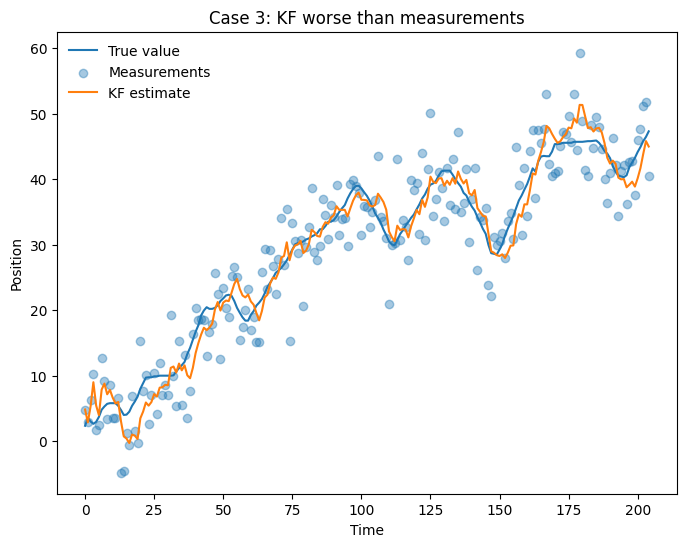

In [38]:
kf3 = kalman_1d(measurements, Q_val=0.0001, R_val=0.1)
plt.figure(figsize=(8, 6))

plt.plot(true, label="True value")
plt.scatter(range(len(true)), measurements, alpha=0.4, label="Measurements")
plt.plot(kf3, label="KF estimate")

plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Case 3: KF worse than measurements")
plt.legend(frameon=False)
plt.show()

### Conclusion

The results obtained from the three scenarios demonstrate that the performance of the Kalman Filter strongly depends on the selection of the parameters $Q$ and $R$.

In the first case, the measurements, the Kalman Filter estimate, and the true value are all close, indicating that the filter is well tuned and effectively balances model predictions with measurement information. As a result, the filter reduces noise and improves the estimation.

In the second case, all three signals differ significantly, showing that a poor parameter configuration leads to inaccurate results. The filter fails to capture the underlying behavior of the system and does not provide a reliable estimate.

In the third case, the measurements are relatively close to the true value, but the Kalman Filter estimate deviates from it. This highlights that an improperly tuned filter can perform worse than the raw measurements, emphasizing that the Kalman Filter is not inherently optimal.

Overall, these results illustrate that the Kalman Filter requires careful tuning, as its effectiveness depends on the balance between model uncertainty and measurement noise. An appropriate choice of $Q$ and $R$ is essential to achieve accurate and reliable estimations.

This analysis demonstrates that the Kalman Filter is a powerful but sensitive tool, whose performance is highly dependent on the assumptions made about the system and the quality of the available data.

## Exercise 3

- Create a signal that contains 2 sine waves of different amplitudes at 1 and 10 Hz as well as a constant term. Plot the time and frequency domain.  
- Plot the time and frequency domain representation of Gaussian distrubuted random noise. Noise tends to contain all frequency components.  
- Add the three signals together but provide an amplitude of 3, 2, and 1 to the sine, trend, and noise, respectively. Observe the time and frequency domain components.  
- Modify the values of "alpha" and "div_factor" to optimize the filter.  
- Modify the filter order and cutoff frequency.  

#### Solution


In this section, we construct a signal composed of:
- A sine wave at 1 Hz (low frequency)
- A sine wave at 10 Hz (high frequency) with a different amplitude
- A constant term representing a trend

This allows us to analyze how different frequency components appear in both time and frequency domains.

In [2]:
# Sampling parameters
fs = 100  # Sampling frequency (Hz)
t = np.arange(0, 2, 1/fs)  # Time vector (2 seconds)

# Signal components
sine_1hz = 2 * np.sin(2*np.pi*1*t)
sine_10hz = 1 * np.sin(2*np.pi*10*t)
constant = 2

# Final signal
signal = sine_1hz + sine_10hz + constant

### Time Domain Representation

The time domain shows how the signal evolves over time.
We expect to see oscillations due to both sine waves and a vertical shift due to the constant term.

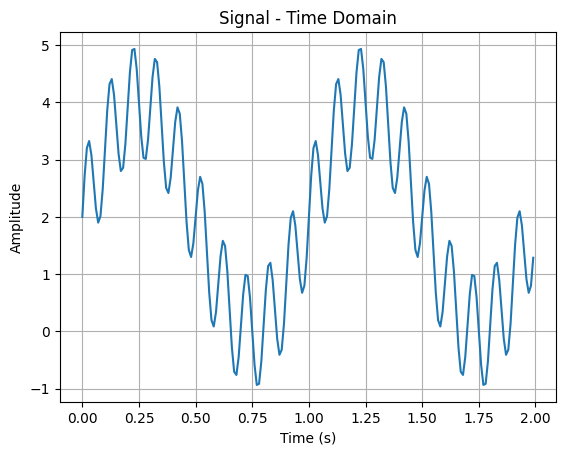

In [3]:
plt.figure()
plt.plot(t, signal)
plt.title("Signal - Time Domain")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

### Frequency Domain Representation

In the time domain, the signal shows a combination of two oscillatory patterns with different speeds, along with a constant upward shift. The slower oscillation corresponds to the 1 Hz sine wave, while the faster fluctuations are due to the 10 Hz component. The constant term shifts the entire signal upward without affecting its shape.

In the frequency domain, obtained using the Fast Fourier Transform (FFT), the signal is decomposed into its frequency components. The plot shows distinct peaks at specific frequencies:

- A peak at 0 Hz corresponds to the constant term (DC component).
- A peak at 1 Hz represents the low-frequency sine wave.
- A peak at 10 Hz represents the high-frequency sine wave.

The height of each peak reflects the amplitude (or strength) of that frequency in the signal. Therefore, the 1 Hz component has a higher peak because it was assigned a larger amplitude compared to the 10 Hz component.

This demonstrates that the FFT does not measure how often a frequency occurs, but rather how strongly it contributes to the overall signal.

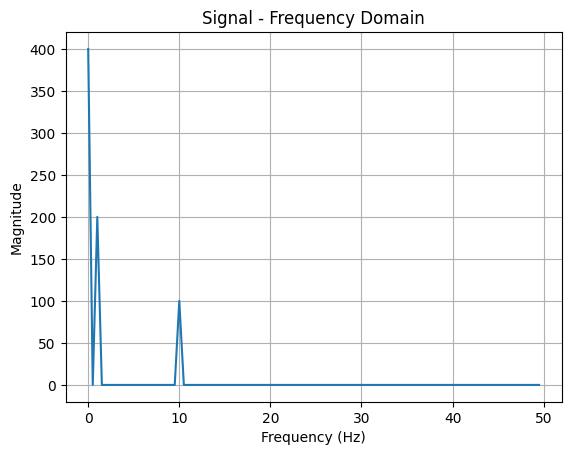

In [4]:
fft_vals = np.fft.fft(signal)
freqs = np.fft.fftfreq(len(t), 1/fs)

plt.figure()
plt.plot(freqs[:len(freqs)//2], np.abs(fft_vals)[:len(freqs)//2])
plt.title("Signal - Frequency Domain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid()
plt.show()

### Gaussian distributed random noise

Gaussian noise is randomly distributed and contains all frequency components.
This is why it is often referred to as "white noise".

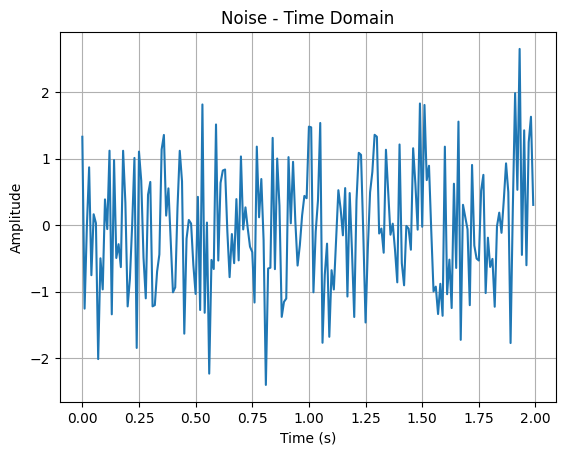

In [5]:
noise = np.random.normal(0, 1, len(t))
plt.figure()
plt.plot(t, noise)
plt.title("Noise - Time Domain")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

### Frequency Domain Representation

The FFT of noise does not show dominant peaks.
Instead, it spreads across all frequencies.

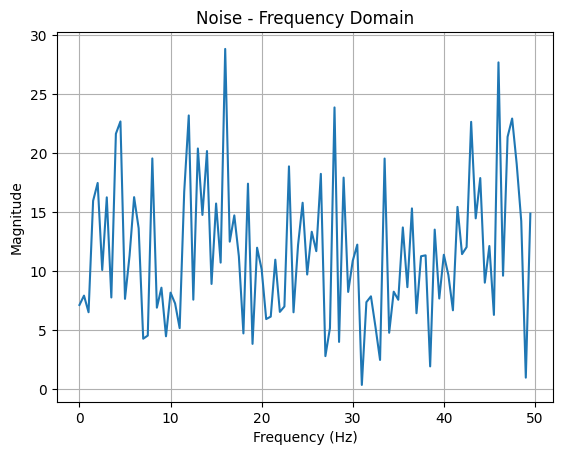

In [6]:
fft_noise = np.fft.fft(noise)

plt.figure()
plt.plot(freqs[:len(freqs)//2], np.abs(fft_noise)[:len(freqs)//2])
plt.title("Noise - Frequency Domain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid()
plt.show()

### Combine signals (amplitudes: 3, 2, 1)


We combine the signals with different weights:
- Sine waves → amplitude 3
- Constant → amplitude 2
- Noise → amplitude 1

This simulates a real-world signal contaminated with noise.

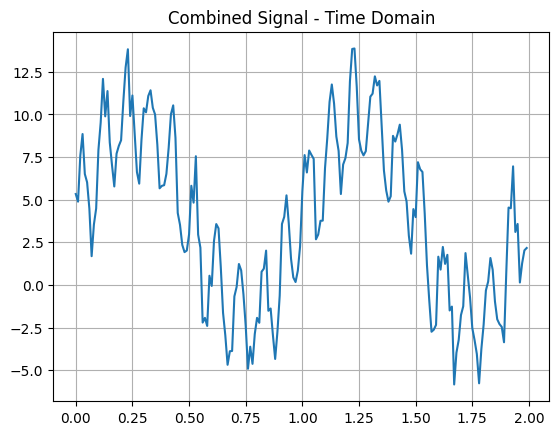

In [7]:
combined = 3*(sine_1hz + sine_10hz) + 2*constant + noise
plt.figure()
plt.plot(t, combined)
plt.title("Combined Signal - Time Domain")
plt.grid()
plt.show()

### Frequency Domain Representation

In the frequency domain, the main peaks at 1 Hz and 10 Hz are still clearly visible, indicating that the original sine wave components are preserved after combining the signals.

However, unlike the previous case, the spectrum now contains many small magnitude values spread across a wide range of frequencies. These small components are introduced by the Gaussian noise.

This occurs because noise contains energy at almost all frequencies, which results in a continuous distribution of low-amplitude values in the FFT plot.

Therefore, the large peaks represent the dominant signal components, while the smaller values correspond to noise. This illustrates how noise affects a signal by spreading energy across the frequency spectrum without removing the main frequencies.

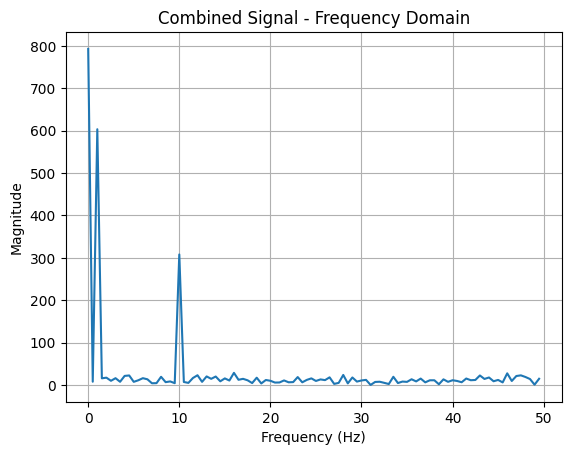

In [8]:
fft_combined = np.fft.fft(combined)

plt.figure()
plt.plot(freqs[:len(freqs)//2], np.abs(fft_combined)[:len(freqs)//2])
plt.title("Combined Signal - Frequency Domain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid()
plt.show()

This process can be understood using a real-world example. Imagine recording sound in an environment where there is a strong удар every second (1 Hz), a softer but faster vibration such as a motor (10 Hz), and background noise from the environment.

The recorded signal is a mixture of all these components. The FFT allows us to separate and identify each frequency present in the signal. The dominant peaks correspond to the main components (1 Hz and 10 Hz), while the smaller values across the spectrum represent noise.

This demonstrates how real-world signals are composed of multiple frequencies that coexist and can be analyzed and filtered.

### Modify alpha and div_factor to optimize the filter

We apply an exponential smoothing filter:
- alpha controls how much weight is given to new data
- div_factor scales the output signal

The goal is to reduce noise while preserving the signal shape.

In [9]:
def exponential_filter(signal, alpha, div_factor):
    filtered = np.zeros_like(signal)
    filtered[0] = signal[0]
    
    for i in range(1, len(signal)):
        filtered[i] = (alpha*signal[i] + (1-alpha)*filtered[i-1]) / div_factor
    
    return filtered

filtered_exp = exponential_filter(combined, alpha=0.2, div_factor=1)

### Plot

The filtered signal appears smoother than the original signal, as the exponential filter reduces high-frequency fluctuations associated with noise. 

While the original signal shows rapid variations caused by the noise component, the filtered signal preserves the general shape and underlying pattern of the data. This demonstrates that the filter effectively attenuates noise while maintaining the main structure of the signal.

However, some loss of detail can be observed, as the filtering process slightly dampens rapid changes in the signal.

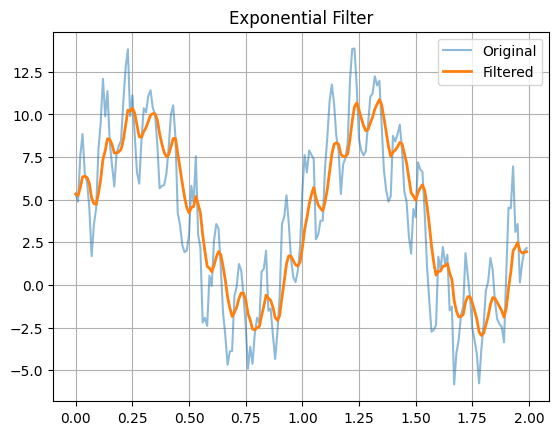

In [10]:
plt.figure()
plt.plot(t, combined, label="Original", alpha=0.5)
plt.plot(t, filtered_exp, label="Filtered", linewidth=2)
plt.legend()
plt.title("Exponential Filter")
plt.grid()
plt.show()

 ### Modify the filter order and cutoff frequency

Three filters were applied to analyze the effect of cutoff frequency and filter order.

The first filter (cutoff = 2, order = 2) removes most high-frequency components, including the 10 Hz signal, resulting in a very smooth signal that mainly preserves the low-frequency component (1 Hz).

The second filter (cutoff = 5, order = 3) provides a balance between noise reduction and signal preservation. It reduces high-frequency noise while maintaining the general structure of the signal.

The third filter (cutoff = 5, order = 5) uses the same cutoff frequency but a higher order, resulting in a sharper filter. This produces a cleaner signal by more effectively removing high-frequency components, although slight distortion may occur.

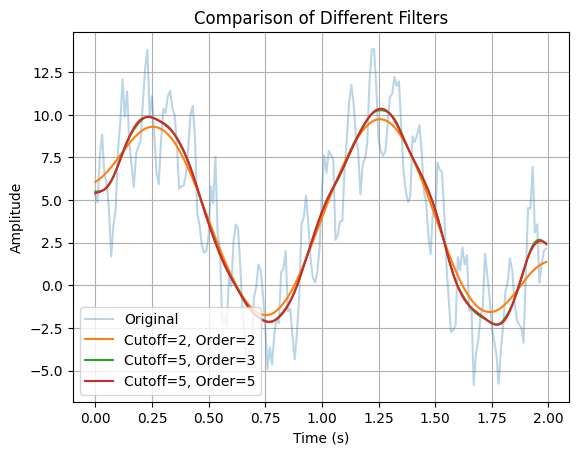

In [ ]:
from scipy.signal import butter, filtfilt

def apply_filter(signal, cutoff, order, fs):
    b, a = butter(order, cutoff/(fs/2), btype='low')
    return filtfilt(b, a, signal)


f1 = apply_filter(combined, cutoff=2, order=2, fs=fs)
f2 = apply_filter(combined, cutoff=5, order=3, fs=fs)
f5 = apply_filter(combined, cutoff=5, order=5, fs=fs)

plt.figure()
plt.plot(t, combined, label="Original", alpha=0.3)

plt.plot(t, f1, label="Cutoff=2, Order=2")
plt.plot(t, f2, label="Cutoff=5, Order=3")
plt.plot(t, f5, label="Cutoff=5, Order=5")

plt.legend()
plt.title("Comparison of Different Filters")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

### Final Conclusion

This exercise demonstrates how signals can be constructed, analyzed, and filtered using both time-domain and frequency-domain approaches. By combining sine waves of different frequencies with a constant term and Gaussian noise, it was possible to simulate a realistic signal containing both structured components and random variability.

The use of the Fast Fourier Transform (FFT) allowed the decomposition of the signal into its frequency components, making it possible to clearly identify the presence of specific frequencies (1 Hz and 10 Hz) as well as the effect of noise, which spreads across the entire spectrum.

Filtering techniques were then applied to reduce noise and isolate relevant components of the signal. The exponential filter provided a simple smoothing approach, while the Butterworth low-pass filter demonstrated how frequency-based filtering can selectively remove high-frequency components. By adjusting the cutoff frequency and filter order, it was possible to control the balance between noise reduction and signal preservation.

Overall, this exercise highlights the importance of understanding both the time and frequency domains when analyzing signals. These techniques are widely applicable in real-world contexts such as economic time series analysis, medical signal processing, engineering systems, and data preprocessing for machine learning, where separating meaningful patterns from noise is essential.